# STRAT-06 Visual Comparison
**Buy-and-Hold · DCA Benchmark · STRAT-06**  
Period: 2017-08-17 → 2026-05-06 &nbsp;|&nbsp; Capital: €52,500 (€500/month × 105)  
Source: `data/reports/strat06_comparative_20260511_193601/`

In [1]:
import json
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

%matplotlib inline

# ── Paths ─────────────────────────────────────────────────────────────────────
REPORT = Path('../data/reports/strat06_comparative_20260511_193601')

with open(REPORT / 'comparative_summary.json') as f:
    SUMMARY = json.load(f)

ec_bah = pd.read_csv(REPORT / 'equity_curve_bah.csv',    parse_dates=['timestamp_utc'])
ec_dca = pd.read_csv(REPORT / 'equity_curve_dca.csv',    parse_dates=['timestamp_utc'])
ec_s06 = pd.read_csv(REPORT / 'equity_curve_strat06.csv', parse_dates=['timestamp_utc'])

# ── Derived: BTC price from BAH (accurate; BAH cash ≈ €52.50 residual) ────────
bah_btc_total = next(s for s in SUMMARY['strategies'] if s['strategy'] == 'buy_and_hold')['btc_accumulated']
ec_bah['btc_price'] = (
    (ec_bah['total_value_eur'] - ec_bah['cash_buy_and_hold_benchmark_eur'])
    / bah_btc_total
)

# ── STRAT-06 pool totals ───────────────────────────────────────────────────────
ec_s06['total_cash'] = (
    ec_s06['cash_strat06_baseline_eur']
    + ec_s06['cash_strat06_buffer_eur']
    + ec_s06['cash_strat06_reserve_eur']
)
ec_s06 = ec_s06.merge(ec_bah[['timestamp_utc', 'btc_price']], on='timestamp_utc', how='left')
price_mask = ec_s06['btc_price'] > 0
ec_s06.loc[price_mask, 'btc_held'] = (
    (ec_s06.loc[price_mask, 'total_value_eur'] - ec_s06.loc[price_mask, 'total_cash'])
    / ec_s06.loc[price_mask, 'btc_price']
)
ec_s06['btc_held'] = ec_s06['btc_held'].fillna(0).clip(lower=0)

# ── DCA total cash ─────────────────────────────────────────────────────────────
ec_dca['total_cash'] = ec_dca['cash_dca_benchmark_eur']

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})
C = {'bah': '#2196F3', 'dca': '#43A047', 's06': '#FF6F00'}
EUR_FMT = mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}')
YR_FMT  = mdates.DateFormatter('%Y')

def _axis_years(ax):
    ax.xaxis.set_major_formatter(YR_FMT)
    ax.xaxis.set_major_locator(mdates.YearLocator())

print('Data loaded. Rows:', len(ec_bah), '| BTC price range:',
      f'€{ec_bah["btc_price"][ec_bah["btc_price"]>0].min():,.0f}',
      '→', f'€{ec_bah["btc_price"].max():,.0f}')

Data loaded. Rows: 3185 | BTC price range: €3,189 → €124,659


## 1 · Equity Curves (log scale)

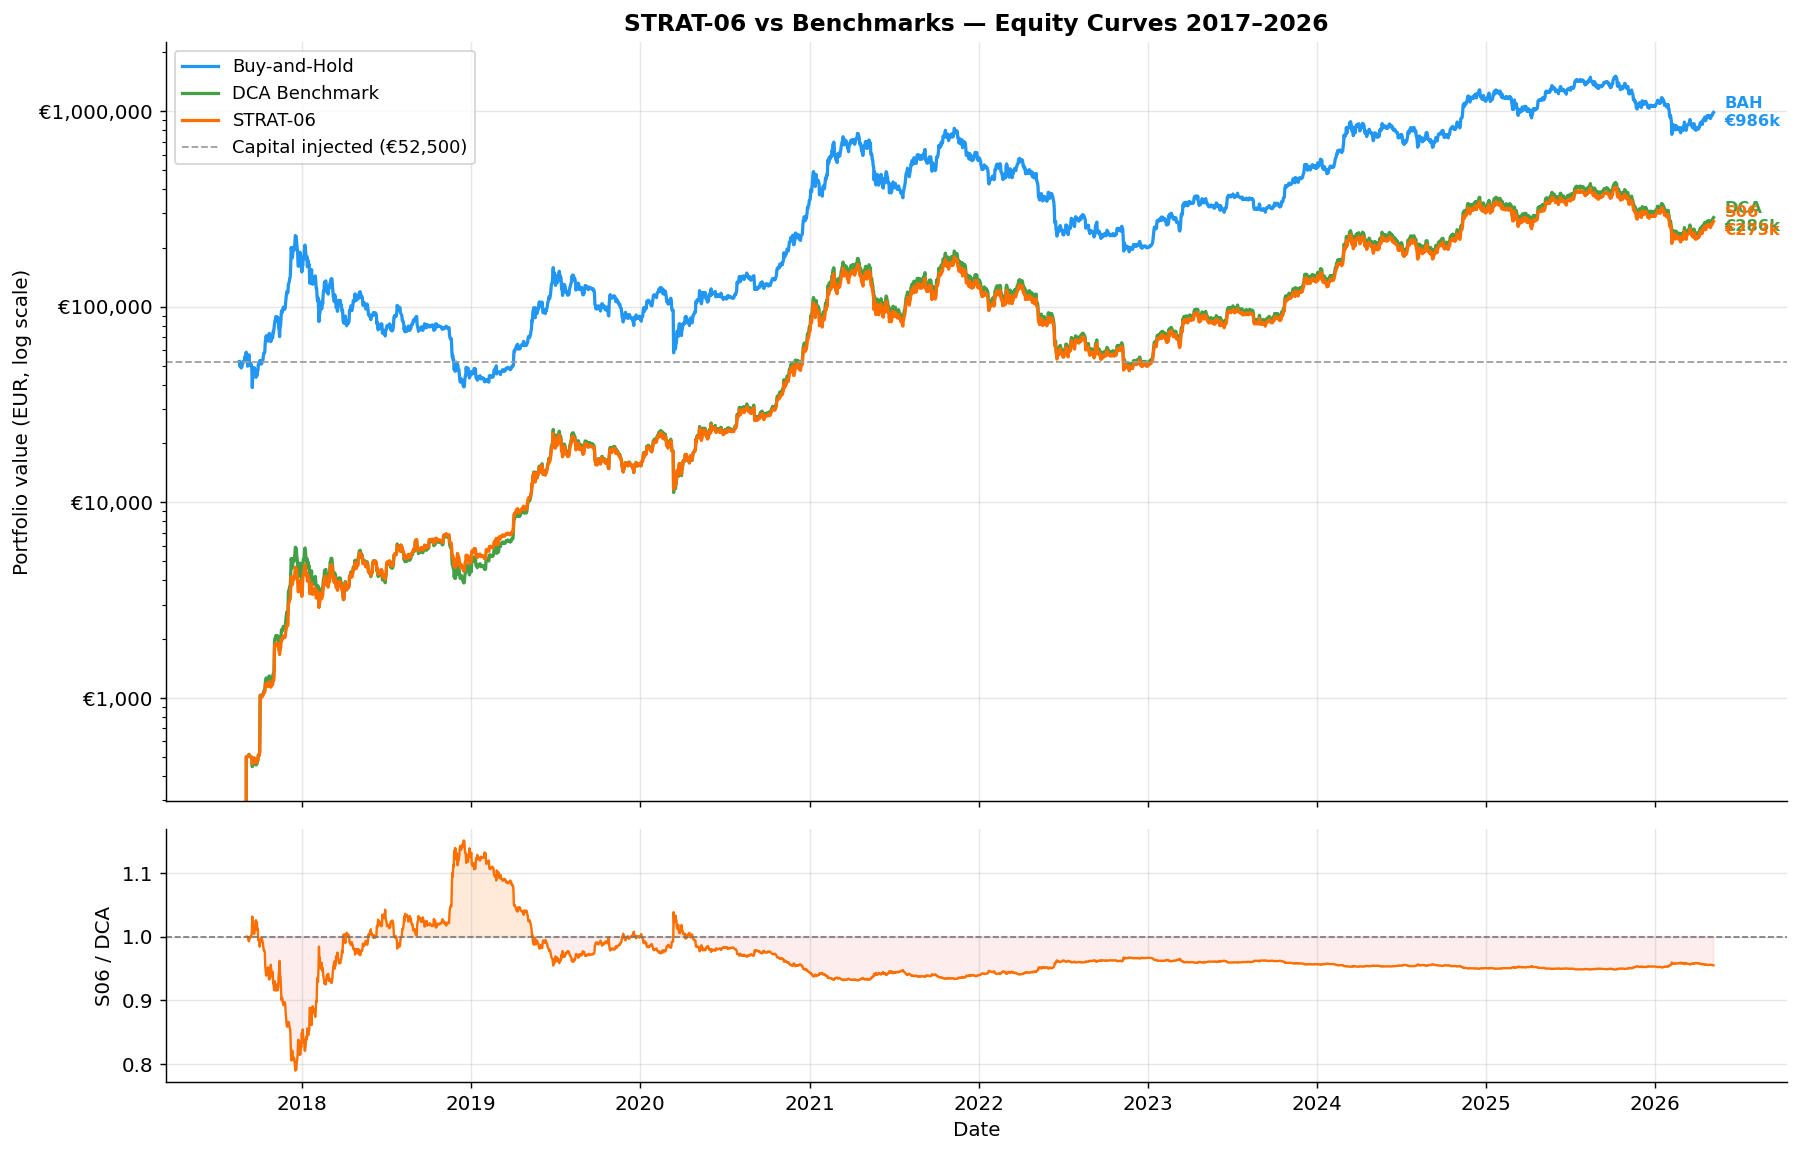

Fig 1: 14×9 in, 2 panels (log equity + S06/DCA ratio)


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_eq, ax_rat = axes

# ── Log equity ────────────────────────────────────────────────────────────────
ax_eq.semilogy(ec_bah['timestamp_utc'], ec_bah['total_value_eur'],
               color=C['bah'], lw=1.8, label='Buy-and-Hold')
ax_eq.semilogy(ec_dca['timestamp_utc'], ec_dca['total_value_eur'],
               color=C['dca'], lw=1.8, label='DCA Benchmark')
ax_eq.semilogy(ec_s06['timestamp_utc'], ec_s06['total_value_eur'],
               color=C['s06'], lw=1.8, label='STRAT-06')
ax_eq.axhline(52_500, color='#9E9E9E', lw=1, ls='--', label='Capital injected (€52,500)')

# Annotate finals
for label, ec, col in [('BAH\n€986k',  ec_bah, C['bah']),
                        ('DCA\n€286k',  ec_dca, C['dca']),
                        ('S06\n€273k',  ec_s06, C['s06'])]:
    ax_eq.annotate(label,
                   xy=(ec['timestamp_utc'].iloc[-1], ec['total_value_eur'].iloc[-1]),
                   xytext=(6, 0), textcoords='offset points',
                   va='center', fontsize=9, color=col, fontweight='bold')

ax_eq.set_ylabel('Portfolio value (EUR, log scale)')
ax_eq.legend(loc='upper left', fontsize=10)
ax_eq.yaxis.set_major_formatter(EUR_FMT)
ax_eq.set_title('STRAT-06 vs Benchmarks — Equity Curves 2017–2026', fontsize=13, fontweight='bold')

# ── STRAT-06 / DCA ratio ──────────────────────────────────────────────────────
merged = ec_s06[['timestamp_utc','total_value_eur']].merge(
    ec_dca[['timestamp_utc','total_value_eur']], on='timestamp_utc', suffixes=('_s','_d'))
ratio = merged['total_value_eur_s'] / merged['total_value_eur_d'].replace(0, np.nan)
ax_rat.plot(merged['timestamp_utc'], ratio, color=C['s06'], lw=1.3)
ax_rat.fill_between(merged['timestamp_utc'], ratio, 1,
                    where=ratio >= 1, alpha=0.15, color=C['s06'])
ax_rat.fill_between(merged['timestamp_utc'], ratio, 1,
                    where=ratio < 1,  alpha=0.10, color='#EF5350')
ax_rat.axhline(1, color='#757575', lw=0.9, ls='--')
ax_rat.set_ylabel('S06 / DCA')
ax_rat.set_xlabel('Date')
_axis_years(ax_rat)

fig.tight_layout()
plt.savefig('/tmp/fig1_equity.png', bbox_inches='tight')
plt.show()
print('Fig 1: 14×9 in, 2 panels (log equity + S06/DCA ratio)')

## 2 · Drawdown Comparison

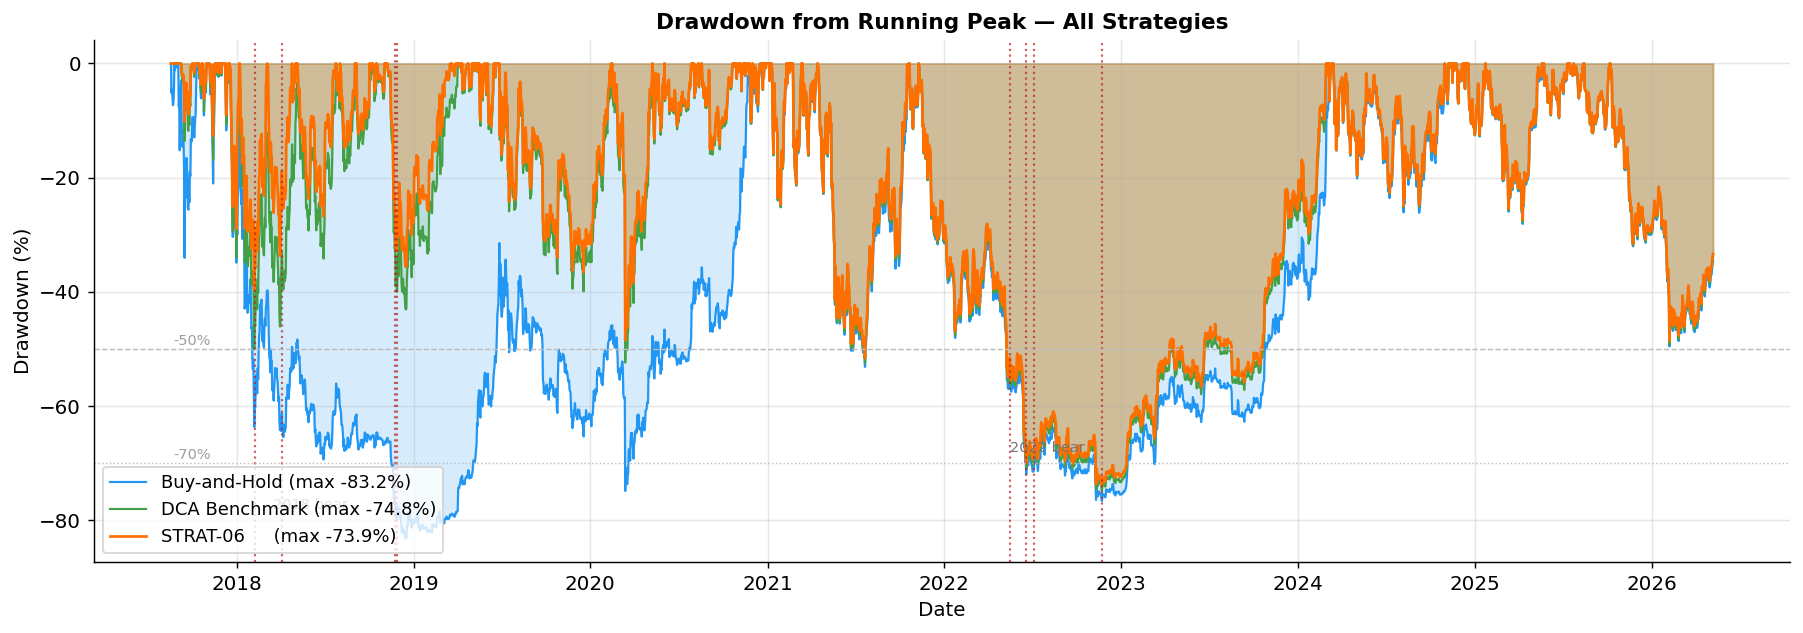

Fig 2: 14×5 in | vertical lines = 8 reserve deploys


In [3]:
def _drawdown(series: pd.Series) -> pd.Series:
    peak = series.expanding().max().where(series.expanding().max() > 0)
    return ((series - peak) / peak).fillna(0) * 100  # in percent

dd_bah = _drawdown(ec_bah['total_value_eur'])
dd_dca = _drawdown(ec_dca['total_value_eur'])
dd_s06 = _drawdown(ec_s06['total_value_eur'])

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(ec_bah['timestamp_utc'], dd_bah, 0, alpha=0.18, color=C['bah'])
ax.fill_between(ec_dca['timestamp_utc'], dd_dca, 0, alpha=0.18, color=C['dca'])
ax.fill_between(ec_s06['timestamp_utc'], dd_s06, 0, alpha=0.30, color=C['s06'])

ax.plot(ec_bah['timestamp_utc'], dd_bah, color=C['bah'], lw=1.2, label=f'Buy-and-Hold (max {dd_bah.min():.1f}%)')
ax.plot(ec_dca['timestamp_utc'], dd_dca, color=C['dca'], lw=1.2, label=f'DCA Benchmark (max {dd_dca.min():.1f}%)')
ax.plot(ec_s06['timestamp_utc'], dd_s06, color=C['s06'], lw=1.5, label=f'STRAT-06     (max {dd_s06.min():.1f}%)')

# Reserve deployment markers on drawdown chart
for dep in SUMMARY['strat06_reserve_deployments']:
    ts = pd.Timestamp(dep['timestamp_utc'])
    ax.axvline(ts, color='#B71C1C', lw=1.2, ls=':', alpha=0.7)

# Threshold lines
for level, ls in [(-50, '--'), (-70, ':')]:
    ax.axhline(level, color='#BDBDBD', lw=0.8, ls=ls)
    ax.text(ec_bah['timestamp_utc'].iloc[5], level + 0.8, f'{level}%',
            color='#9E9E9E', fontsize=8)

ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')
ax.set_title('Drawdown from Running Peak — All Strategies', fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
_axis_years(ax)

# Secondary annotation: bear market labels
ax.text(pd.Timestamp('2018-06-01'), -78, '2018 bear', ha='center', fontsize=8, color='#757575')
ax.text(pd.Timestamp('2022-08-01'), -68, '2022 bear', ha='center', fontsize=8, color='#757575')

fig.tight_layout()
plt.savefig('/tmp/fig2_drawdown.png', bbox_inches='tight')
plt.show()
print(f'Fig 2: 14×5 in | vertical lines = {len(SUMMARY["strat06_reserve_deployments"])} reserve deploys')

## 3 · STRAT-06 Pool Cash Breakdown

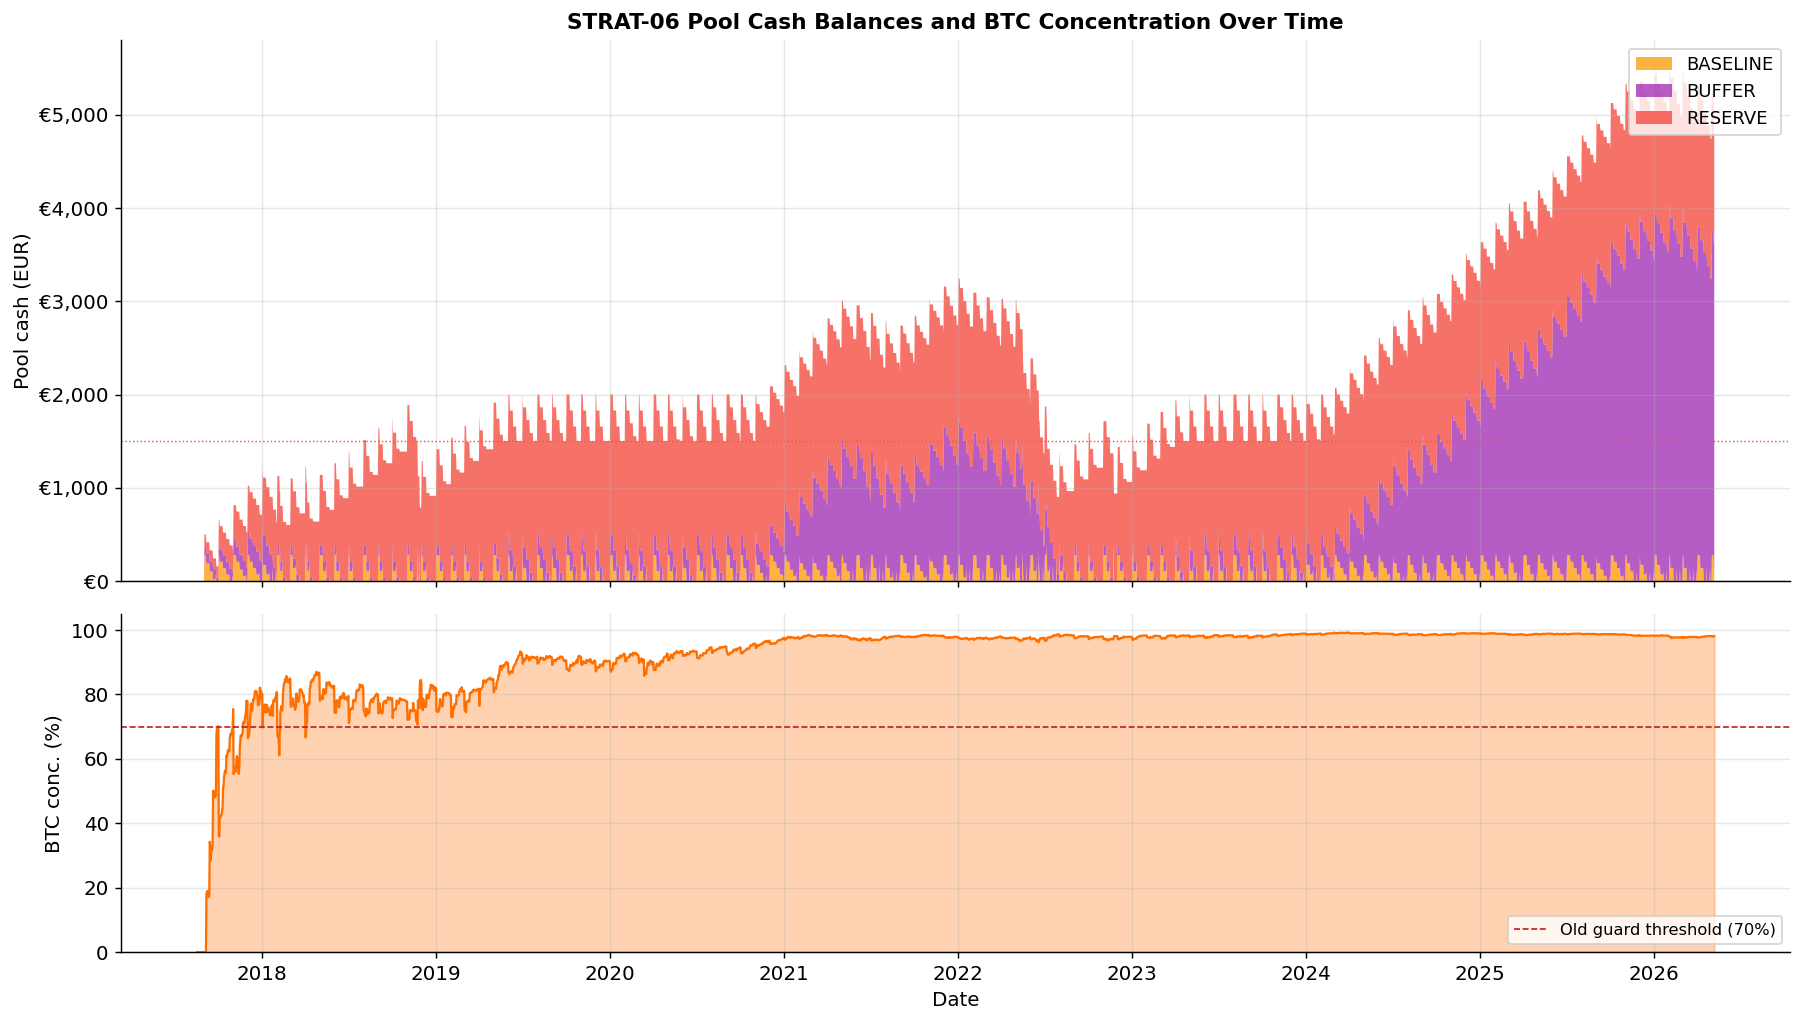

Fig 3: 14×8 in | Final pool cash: BL=€138  BUF=€3468  RES=€1500
BTC concentration: min=17.1%  max=99.2%


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [1.6, 1]})
ax_pool, ax_conc = axes

# ── Stacked area: pool cash ────────────────────────────────────────────────────
dates = ec_s06['timestamp_utc']
bl  = ec_s06['cash_strat06_baseline_eur']
buf = ec_s06['cash_strat06_buffer_eur']
res = ec_s06['cash_strat06_reserve_eur']

ax_pool.stackplot(dates, bl, buf, res,
                  labels=['BASELINE', 'BUFFER', 'RESERVE'],
                  colors=['#FF9800', '#9C27B0', '#F44336'],
                  alpha=0.75)
ax_pool.set_ylabel('Pool cash (EUR)')
ax_pool.yaxis.set_major_formatter(EUR_FMT)
ax_pool.legend(loc='upper right', fontsize=10)
ax_pool.set_title('STRAT-06 Pool Cash Balances and BTC Concentration Over Time',
                  fontsize=12, fontweight='bold')

# Reserve cap reference line
res_cap = 1_500.0
ax_pool.axhline(res_cap, color='#EF5350', lw=0.8, ls=':', label=f'Reserve cap (€{res_cap:,.0f})')

# ── BTC concentration ─────────────────────────────────────────────────────────
btc_conc = ec_s06['btc_held'] * ec_s06['btc_price'] / ec_s06['total_value_eur'].replace(0, np.nan)
btc_conc = btc_conc.fillna(0) * 100  # percent

ax_conc.fill_between(dates, btc_conc, 0, alpha=0.3, color=C['s06'])
ax_conc.plot(dates, btc_conc, color=C['s06'], lw=1.2)
ax_conc.axhline(70, color='#B71C1C', lw=0.9, ls='--', label='Old guard threshold (70%)')
ax_conc.set_ylabel('BTC conc. (%)')
ax_conc.set_xlabel('Date')
ax_conc.legend(loc='lower right', fontsize=9)
ax_conc.set_ylim(0, 105)
_axis_years(ax_conc)

fig.tight_layout()
plt.savefig('/tmp/fig3_pools.png', bbox_inches='tight')
plt.show()

final_bl  = ec_s06['cash_strat06_baseline_eur'].iloc[-1]
final_buf = ec_s06['cash_strat06_buffer_eur'].iloc[-1]
final_res = ec_s06['cash_strat06_reserve_eur'].iloc[-1]
print(f'Fig 3: 14×8 in | Final pool cash: BL=€{final_bl:.0f}  BUF=€{final_buf:.0f}  RES=€{final_res:.0f}')
print(f'BTC concentration: min={btc_conc[btc_conc>0].min():.1f}%  max={btc_conc.max():.1f}%')

## 4 · BTC Accumulation Over Time

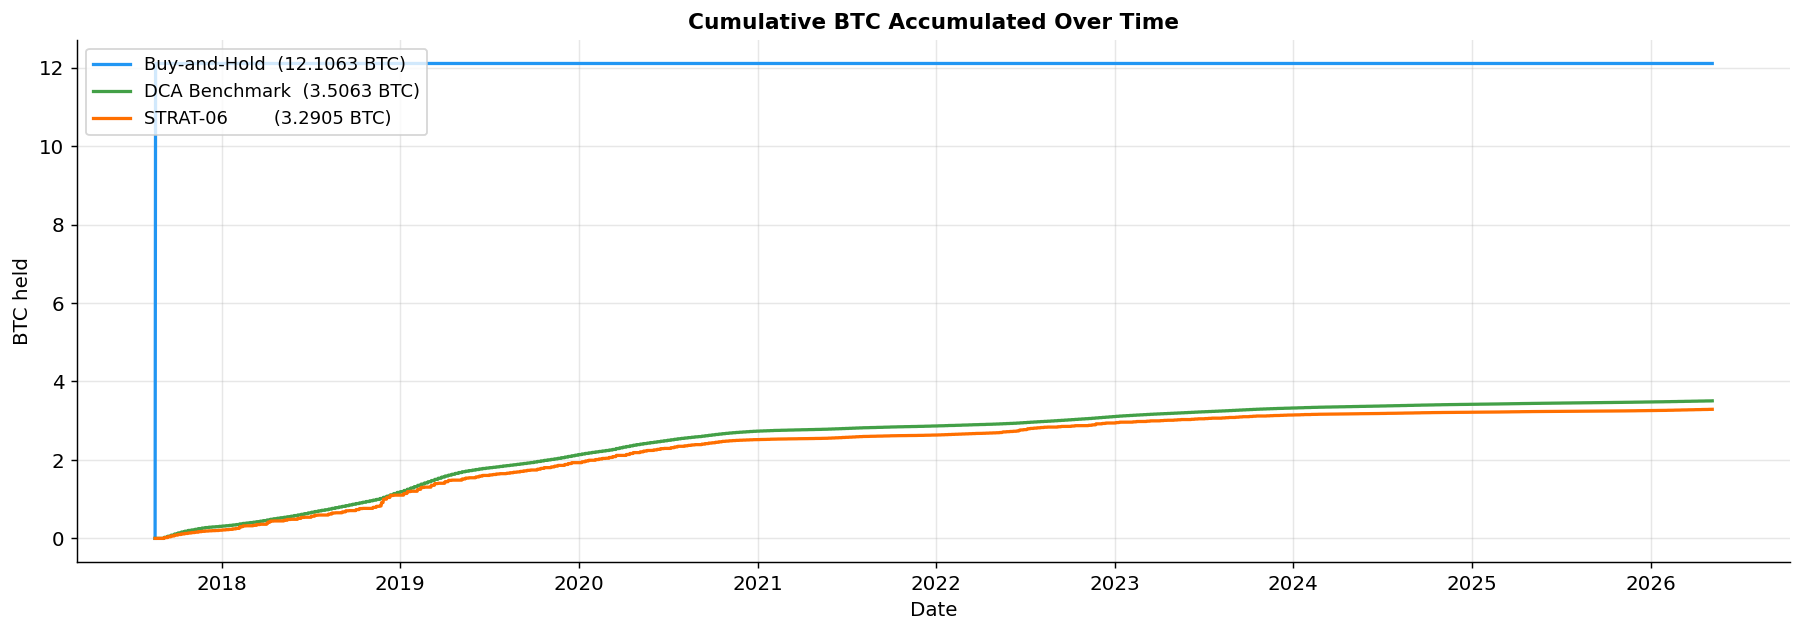

Fig 4: 14×5 in | Final BTC: BAH=12.1063  DCA=3.5063  S06=3.2905


In [5]:
# BTC held per strategy per bar
price_safe = ec_bah['btc_price'].replace(0, np.nan)

btc_bah = (ec_bah['total_value_eur'] - ec_bah['cash_buy_and_hold_benchmark_eur']) / price_safe
btc_dca = (ec_dca['total_value_eur'] - ec_dca['total_cash']) / price_safe
btc_s06 = ec_s06['btc_held']

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ec_bah['timestamp_utc'], btc_bah.fillna(0), color=C['bah'], lw=1.8,
        label=f'Buy-and-Hold  ({btc_bah.iloc[-1]:.4f} BTC)')
ax.plot(ec_dca['timestamp_utc'], btc_dca.fillna(0), color=C['dca'], lw=1.8,
        label=f'DCA Benchmark  ({btc_dca.iloc[-1]:.4f} BTC)')
ax.plot(ec_s06['timestamp_utc'], btc_s06.fillna(0), color=C['s06'], lw=1.8,
        label=f'STRAT-06        ({btc_s06.iloc[-1]:.4f} BTC)')

ax.set_ylabel('BTC held')
ax.set_xlabel('Date')
ax.set_title('Cumulative BTC Accumulated Over Time', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
_axis_years(ax)

fig.tight_layout()
plt.savefig('/tmp/fig4_btc_accum.png', bbox_inches='tight')
plt.show()
print('Fig 4: 14×5 in | Final BTC:',
      f'BAH={btc_bah.iloc[-1]:.4f}  DCA={btc_dca.iloc[-1]:.4f}  S06={btc_s06.iloc[-1]:.4f}')

## 5 · Reserve Deployments Timeline

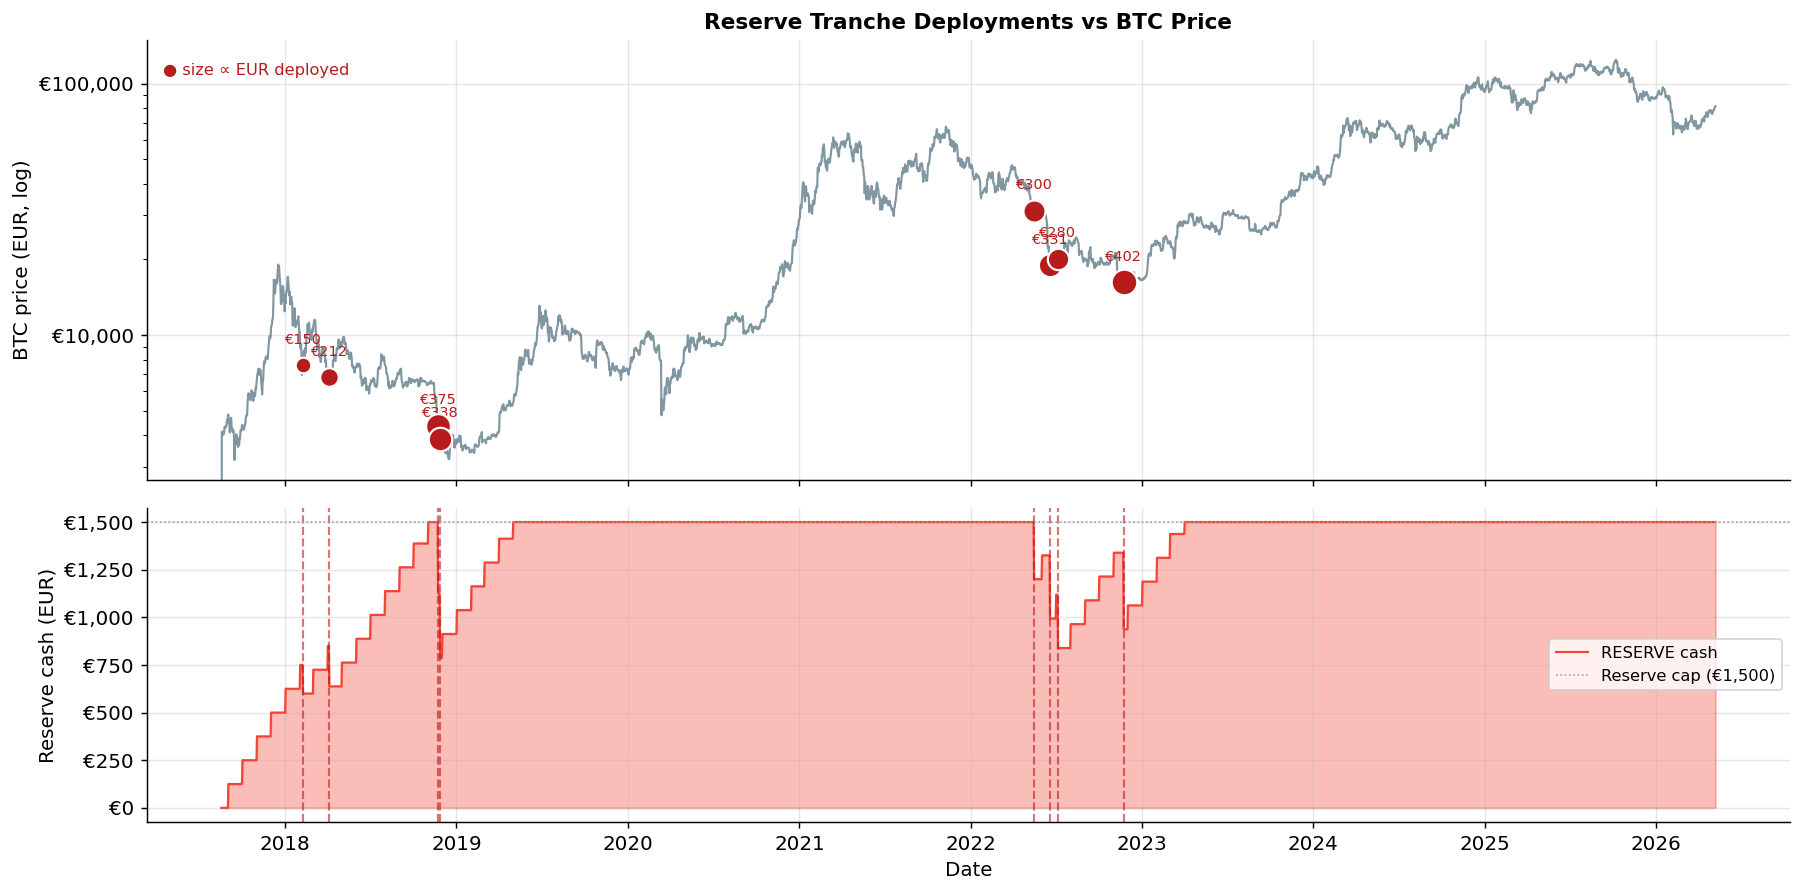

Fig 5: 14×7 in | 8 deployments — amounts: €150, €212, €375, €338, €300, €331, €280, €402


In [6]:
dep_df = pd.DataFrame(SUMMARY['strat06_reserve_deployments'])
dep_df['timestamp_utc'] = pd.to_datetime(dep_df['timestamp_utc'])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [1.4, 1]})
ax_price, ax_res = axes

# ── BTC price (log) ───────────────────────────────────────────────────────────
ax_price.semilogy(ec_bah['timestamp_utc'], ec_bah['btc_price'],
                  color='#607D8B', lw=1.2, alpha=0.8)

for _, row in dep_df.iterrows():
    # Approx price at deployment
    price_at = ec_bah.loc[ec_bah['timestamp_utc'].searchsorted(row['timestamp_utc']), 'btc_price']
    ax_price.scatter(row['timestamp_utc'], price_at,
                     s=row['amount_deployed_eur'] * 0.5,  # size ∝ amount
                     color='#B71C1C', zorder=5, edgecolors='white', lw=1.2)
    ax_price.annotate(f"€{row['amount_deployed_eur']:.0f}",
                      xy=(row['timestamp_utc'], price_at),
                      xytext=(0, 12), textcoords='offset points',
                      ha='center', fontsize=8, color='#B71C1C')

ax_price.set_ylabel('BTC price (EUR, log)')
ax_price.yaxis.set_major_formatter(EUR_FMT)
ax_price.set_title('Reserve Tranche Deployments vs BTC Price', fontsize=12, fontweight='bold')
ax_price.text(0.01, 0.92, '● size ∝ EUR deployed', transform=ax_price.transAxes,
              color='#B71C1C', fontsize=9)

# ── Reserve balance ────────────────────────────────────────────────────────────
ax_res.fill_between(ec_s06['timestamp_utc'], ec_s06['cash_strat06_reserve_eur'],
                    alpha=0.35, color='#F44336')
ax_res.plot(ec_s06['timestamp_utc'], ec_s06['cash_strat06_reserve_eur'],
            color='#F44336', lw=1.2, label='RESERVE cash')

for _, row in dep_df.iterrows():
    ax_res.axvline(row['timestamp_utc'], color='#B71C1C', lw=1.2, ls='--', alpha=0.6)

ax_res.axhline(1_500, color='#9E9E9E', lw=0.9, ls=':', label='Reserve cap (€1,500)')
ax_res.set_ylabel('Reserve cash (EUR)')
ax_res.set_xlabel('Date')
ax_res.yaxis.set_major_formatter(EUR_FMT)
ax_res.legend(fontsize=9)
_axis_years(ax_res)

fig.tight_layout()
plt.savefig('/tmp/fig5_reserve.png', bbox_inches='tight')
plt.show()

print(f'Fig 5: 14×7 in | {len(dep_df)} deployments — amounts:',
      ', '.join(f'€{r:.0f}' for r in dep_df['amount_deployed_eur']))

## 6 · Risk-Adjusted Metrics + Cost Basis

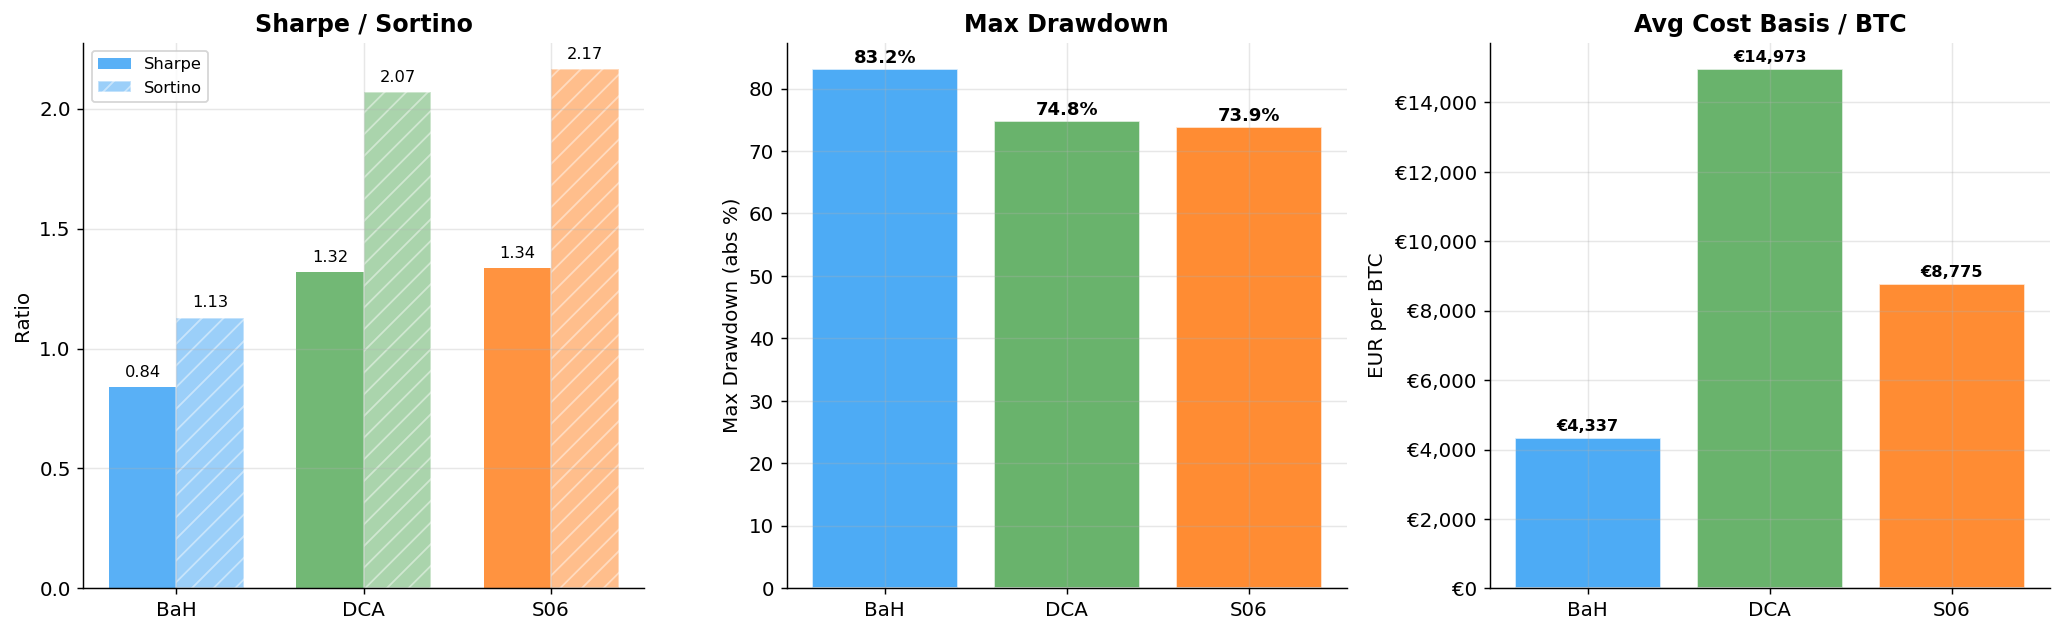

Fig 6: 16×5 in | Sharpe: [0.8391, 1.3173, 1.3358] | Sortino: [1.129, 2.0687, 2.1667]
MaxDD: [83.17, 74.79, 73.87] | Cost basis: ['€4,337', '€14,973', '€8,775']


In [7]:
strats_json = SUMMARY['strategies']
labels = ['Buy-and-Hold', 'DCA Benchmark', 'STRAT-06']
keys   = ['buy_and_hold', 'dca_benchmark', 'strat06']
colors = [C['bah'], C['dca'], C['s06']]

def _val(key, field):
    return next(s[field] for s in strats_json if s['strategy'] == key)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Sharpe & Sortino ───────────────────────────────────────────────────────────
ax = axes[0]
x = np.arange(3)
w = 0.36
sharpe  = [_val(k, 'sharpe_ratio') or 0 for k in keys]
sortino = [_val(k, 'sortino_ratio') or 0 for k in keys]
b1 = ax.bar(x - w/2, sharpe,  w, color=colors, alpha=0.75, label='Sharpe')
b2 = ax.bar(x + w/2, sortino, w, color=colors, alpha=0.45, label='Sortino', hatch='//', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(['BaH', 'DCA', 'S06'])
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Ratio')
ax.set_title('Sharpe / Sortino', fontweight='bold')
ax.legend(fontsize=9)

# ── MaxDD bars ─────────────────────────────────────────────────────────────────
ax = axes[1]
maxdd = [abs(_val(k, 'max_drawdown_pct')) for k in keys]
bars  = ax.bar(['BaH', 'DCA', 'S06'], maxdd, color=colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, maxdd):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Max Drawdown (abs %)')
ax.set_title('Max Drawdown', fontweight='bold')

# ── Avg cost basis bar ─────────────────────────────────────────────────────────
ax = axes[2]
bah_cost = _val('buy_and_hold', 'total_invested_eur') / _val('buy_and_hold', 'btc_accumulated')
dca_cost = _val('dca_benchmark', 'total_invested_eur') / _val('dca_benchmark', 'btc_accumulated')
s06_cost = _val('strat06', 'avg_cost_basis_eur_per_btc')
costs = [bah_cost, dca_cost, s06_cost]
bars = ax.bar(['BaH', 'DCA', 'S06'], costs, color=colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'€{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('EUR per BTC')
ax.set_title('Avg Cost Basis / BTC', fontweight='bold')
ax.yaxis.set_major_formatter(EUR_FMT)

fig.tight_layout()
plt.savefig('/tmp/fig6_metrics.png', bbox_inches='tight')
plt.show()
print(f'Fig 6: 16×5 in | Sharpe: {sharpe} | Sortino: {sortino}')
print(f'MaxDD: {maxdd} | Cost basis: {[f"€{c:,.0f}" for c in costs]}')

## 7 · Capital Deployment Waterfall

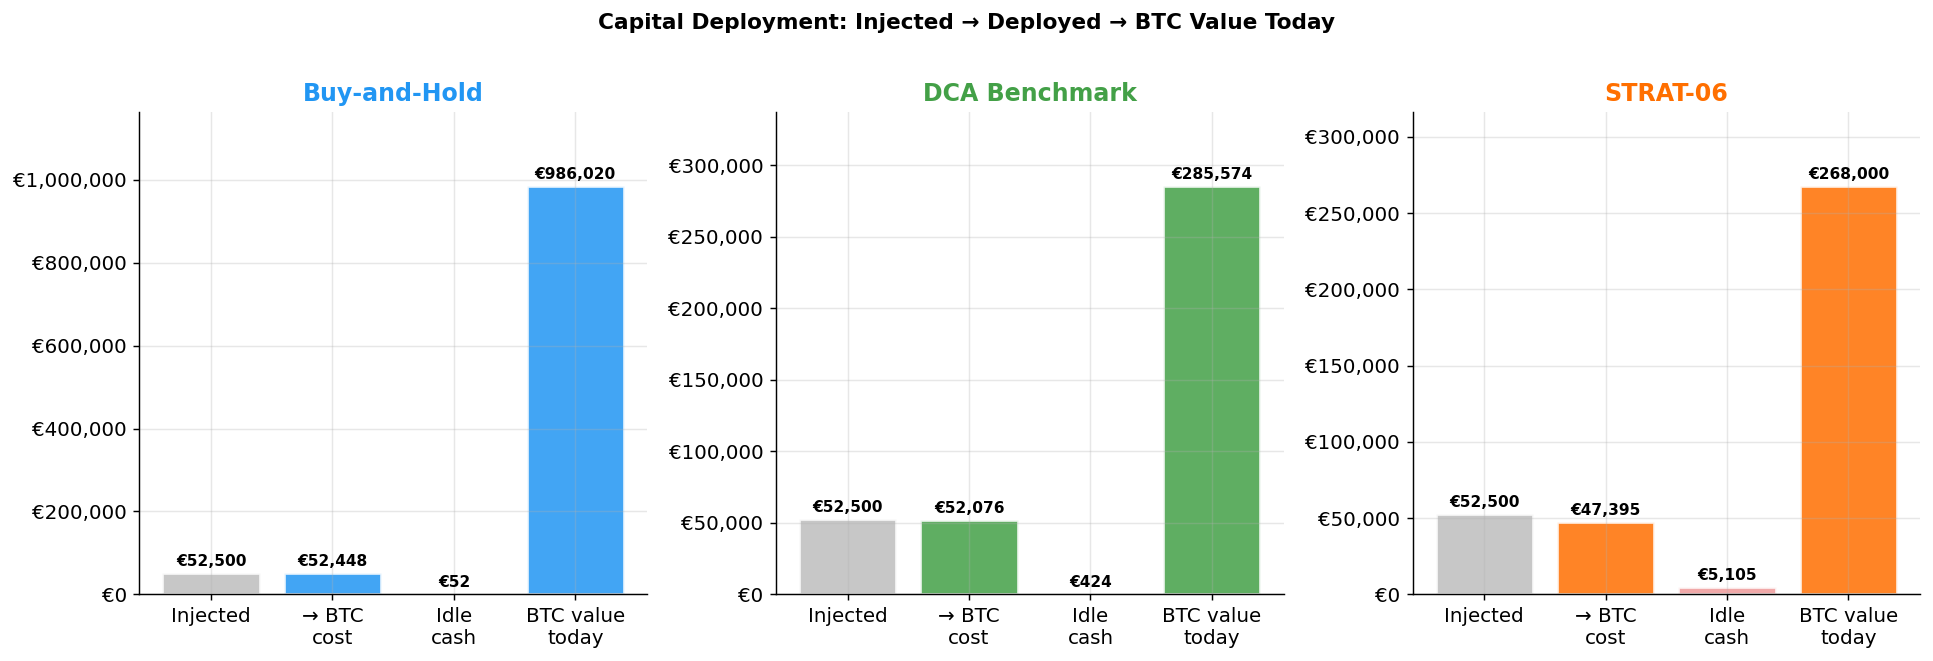

Fig 7: 15×5 in | 3 waterfall panels (1 per strategy)
  buy_and_hold        : deployed 99.9%, idle €52
  dca_benchmark       : deployed 99.2%, idle €424
  strat06             : deployed 90.3%, idle €5,105


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

total_inj = 52_500.0

for ax, (key, label, color) in zip(axes, [
    ('buy_and_hold',  'Buy-and-Hold', C['bah']),
    ('dca_benchmark', 'DCA Benchmark', C['dca']),
    ('strat06',       'STRAT-06', C['s06']),
]):
    s = next(x for x in strats_json if x['strategy'] == key)
    deployed = total_inj - s['cash_remaining_eur']
    idle     = s['cash_remaining_eur']
    btc_val  = s['final_value_eur'] - s['cash_remaining_eur']

    bars_data = [('Injected', total_inj, '#BDBDBD'),
                 ('→ BTC\ncost', deployed, color),
                 ('Idle\ncash', idle, '#EF9A9A'),
                 ('BTC value\ntoday', btc_val, color)]

    bar_labels = [b[0] for b in bars_data]
    bar_vals   = [b[1] for b in bars_data]
    bar_cols   = [b[2] for b in bars_data]

    bars = ax.bar(bar_labels, bar_vals, color=bar_cols, alpha=0.85,
                  edgecolor='white', lw=1.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + bar_vals[-1] * 0.01,
                f'€{bar.get_height():,.0f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

    ax.set_title(label, fontweight='bold', color=color)
    ax.yaxis.set_major_formatter(EUR_FMT)
    ax.set_ylim(0, max(bar_vals) * 1.18)

fig.suptitle('Capital Deployment: Injected → Deployed → BTC Value Today',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('/tmp/fig7_waterfall.png', bbox_inches='tight')
plt.show()
print('Fig 7: 15×5 in | 3 waterfall panels (1 per strategy)')
for s in strats_json:
    pct = (1 - s['cash_remaining_eur'] / total_inj) * 100
    print(f"  {s['strategy']:<20}: deployed {pct:.1f}%, idle €{s['cash_remaining_eur']:,.0f}")

## 8 · Comparative Metrics Summary Table

In [9]:
rows = []
for s in strats_json:
    label = {'buy_and_hold': 'Buy-and-Hold',
             'dca_benchmark': 'DCA Benchmark',
             'strat06': 'STRAT-06'}[s['strategy']]
    rows.append({
        'Strategy':       label,
        'Final value':    f"€{s['final_value_eur']:,.0f}",
        'BTC held':       f"{s['btc_accumulated']:.4f}",
        'Total return':   f"{s['total_return_pct']:.1f}%",
        'CAGR':           f"{s['cagr_pct']:.1f}%" if s['cagr_pct'] else 'N/A',
        'Max drawdown':   f"{s['max_drawdown_pct']:.1f}%",
        'Sharpe':         f"{s['sharpe_ratio']:.2f}" if s['sharpe_ratio'] else 'N/A',
        'Sortino':        f"{s['sortino_ratio']:.2f}" if s['sortino_ratio'] else 'N/A',
        'Idle cash':      f"€{s['cash_remaining_eur']:,.0f}",
        'Fees paid':      f"€{s['total_fees_paid_eur']:.0f}",
    })

df_summary = pd.DataFrame(rows).set_index('Strategy')

# Pretty-print with color hints via Styler
try:
    display(df_summary.style
            .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold')]}])
            .set_caption('Comparative Performance Summary — 2017-08-17 → 2026-05-06'))
except Exception:
    print(df_summary.to_string())

er = SUMMARY['excess_returns']
print(f"\nSTRAT-06 excess return vs Buy-and-Hold : {er['strat06_vs_bah_pct']:+.1f} pp")
print(f"STRAT-06 excess return vs DCA Benchmark: {er['strat06_vs_dca_pct']:+.1f} pp")

,Final value,BTC held,Total return,CAGR,Max drawdown,Sharpe,Sortino,Idle cash,Fees paid
Strategy,,,,,,,,,
Buy-and-Hold,"€986,072",12.1063,1778.2%,40.0%,-83.2%,0.84,1.13,€52,€52
DCA Benchmark,"€285,998",3.5063,444.8%,N/A,-74.8%,1.32,2.07,€424,€52
STRAT-06,"€273,105",3.2905,420.2%,N/A,-73.9%,1.34,2.17,"€5,105",€47



STRAT-06 excess return vs Buy-and-Hold : -1358.0 pp
STRAT-06 excess return vs DCA Benchmark: -24.6 pp
